## 1. Introduction

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/johnolafenwa/us-census-data/adult-training.csv
/kaggle/input/datasets/johnolafenwa/us-census-data/adult-test.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
filepath_train = '/kaggle/input/datasets/johnolafenwa/us-census-data/adult-training.csv'
filepath_test = '/kaggle/input/datasets/johnolafenwa/us-census-data/adult-test.csv'

adult_train = pd.read_csv(
    filepath_train,
    header=None,
    sep=",",
    skipinitialspace=True
)

adult_test = test = pd.read_csv(
    filepath_test,
    header=None,
    skiprows=1,
    sep=",",
    engine="python"
)

In [4]:
adult_train.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
adult_train.describe()

,0,2,4,10,11,12
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [6]:
adult_test.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K.
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K.
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K.
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K.
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K.


In [7]:
adult_test.describe()

,0,2,4,10,11,12
count,16281.000000,1.628100e+04,16281.000000,16281.000000,16281.000000,16281.000000
mean,38.767459,1.894357e+05,10.072907,1081.905104,87.899269,40.392236
std,13.849187,1.057149e+05,2.567545,7583.935968,403.105286,12.479332
min,17.000000,1.349200e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.167360e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.778310e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.383840e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,3770.000000,99.000000


## 2. Exploritory Data Analysis

In [8]:
print(f'Train Shape, {adult_train.shape}, Train Duplicates, {adult_train.duplicated().sum()}, Train Null Count {adult_train.isna().sum().sum()}')
print(f'Test Shape, {adult_test.shape},Test Duplicates, {adult_test.duplicated().sum()}, Test Null Count {adult_test.isna().sum().sum()}')


Train Shape, (32561, 15), Train Duplicates, 24, Train Null Count 0
Test Shape, (16281, 15),Test Duplicates, 5, Test Null Count 0


In [9]:
#Dropping Duplicates
train = adult_train.drop_duplicates()
test = adult_test.drop_duplicates()

In [10]:
#Renaming Columns 
train = train.rename(columns={0: "age", 1: "workclass", 2:'fnlwgt', 3:'education', 4:'education_num',
                     5:'marital_status', 6:'occupation', 7:'relationship', 8:'race', 9:'gender', 10:'capital_gain',
                             11:'capital_loss', 12:'hours_per_week',13:'native_country',14:'income_bracket'})

test= test.rename(columns={0: "age", 1: "workclass", 2:'fnlwgt', 3:'education', 4:'education_num',
                     5:'marital_status', 6:'occupation', 7:'relationship', 8:'race', 9:'gender', 10:'capital_gain',
                             11:'capital_loss', 12:'hours_per_week',13:'native_country',14:'income_bracket'})

In [11]:
test.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,gender,capital_gain,capital_loss,hours_per_week,native_country,income_bracket
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K.
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K.
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K.
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K.
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K.


In [12]:
print((train == '?').sum().sum())
print((test == '?').sum().sum())

4261
0


In [13]:
train.replace("?", np.nan, inplace=True)
#test.replace("?", np.nan, inplace=True)

train.dropna(inplace=True)

In [14]:
test.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,gender,capital_gain,capital_loss,hours_per_week,native_country,income_bracket
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K.
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K.
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K.
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K.
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K.


In [15]:
print((test == " ?").sum().sum())

2203


In [16]:
#Remove leading whitespace
train = train.apply(
    lambda col: col.str.strip() if col.dtype == "object" else col
)

test = test.apply(
    lambda col: col.str.strip() if col.dtype == "object" else col
)

In [17]:
test.replace("?", np.nan, inplace=True)

In [18]:
print(train.isna().sum().sum())
print(test.isna().sum().sum())

0
2203


In [19]:
#Drop Null Values in Test
test.dropna(inplace=True)

train.reset_index(drop=True, inplace=True)
test.reset_index(drop=True, inplace=True)

In [20]:
print(f'Train shape, {train.shape}, Test shape{test.shape}')

Train shape, (30139, 15), Test shape(15055, 15)


education and educational_num are the same values, education will be dropped

In [21]:
train.drop(columns=["education"], inplace=True)
test.drop(columns=["education"], inplace=True)

In [22]:
train.head()

,age,workclass,fnlwgt,education_num,marital_status,occupation,relationship,race,gender,capital_gain,capital_loss,hours_per_week,native_country,income_bracket
0,39,State-gov,77516,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [23]:
train['income_bracket'].nunique()

2

'income_bracket' is binary class with values <=50K and >50. Since this feature is target variable, will be encoded as 0 or 1. 

In [24]:

train["income_bracket"] = train["income_bracket"].str.replace(".", "", regex=False)
test["income_bracket"]  = test["income_bracket"].str.replace(".", "", regex=False)

train["income_bracket"] = (train["income_bracket"] == ">50K").astype(int)
test["income_bracket"]  = (test["income_bracket"] == ">50K").astype(int)

In [25]:
train["income_bracket"].value_counts(normalize=True)

income_bracket
0    0.750954
1    0.249046
Name: proportion, dtype: float64

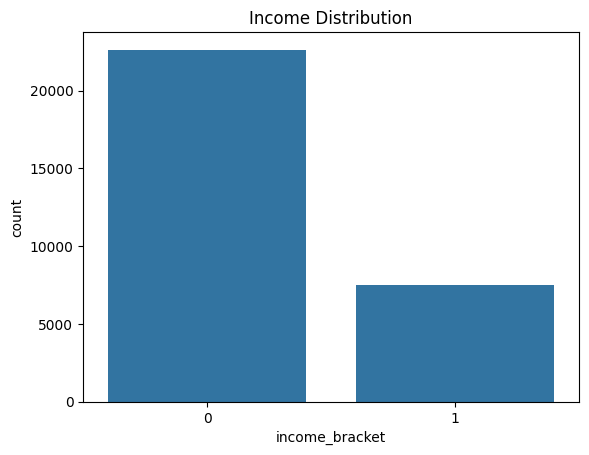

In [26]:
sns.countplot(x="income_bracket", data=train)
plt.title("Income Distribution")
plt.show()

In [27]:
target_col = "income_bracket"

cat_cols = [
    "workclass",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "gender",
    "native_country"
]

num_cols = [
    "age",
    "fnlwgt",
    "education_num",
    "capital_gain",
    "capital_loss",
    "hours_per_week"
]

In [28]:
train[num_cols].describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,30139.000000,3.013900e+04,30139.000000,30139.000000,30139.000000,30139.000000
mean,38.441720,1.897950e+05,10.122532,1092.841202,88.439928,40.934703
std,13.131426,1.056586e+05,2.548738,7409.110596,404.445239,11.978753
min,17.000000,1.376900e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.176275e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.784170e+05,10.000000,0.000000,0.000000,40.000000
75%,47.000000,2.376045e+05,13.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


<Axes: xlabel='capital_gain', ylabel='Count'>

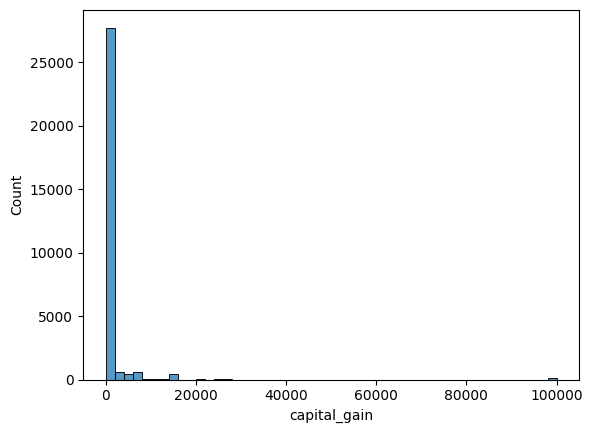

In [29]:
sns.histplot(train["capital_gain"], bins=50)

<Axes: xlabel='income_bracket', ylabel='age'>

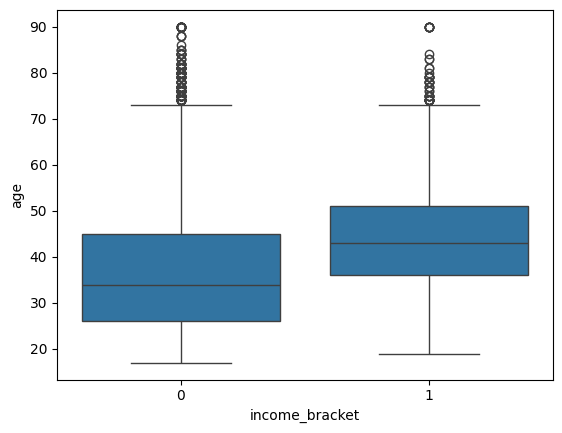

In [30]:
sns.boxplot(x="income_bracket", y="age", data=train)

Individuals in the >50K income bracket tend to be older on average, suggesting that income increases with experience and career progression.

<Axes: xlabel='education_num', ylabel='count'>

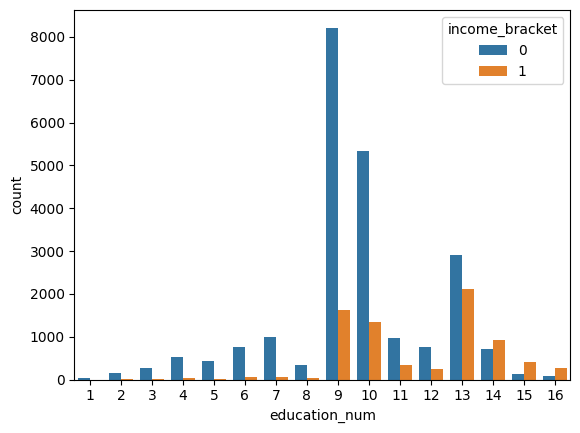

In [31]:
sns.countplot(x="education_num", hue="income_bracket", data=train)

<Axes: xlabel='income_bracket', ylabel='capital_gain'>

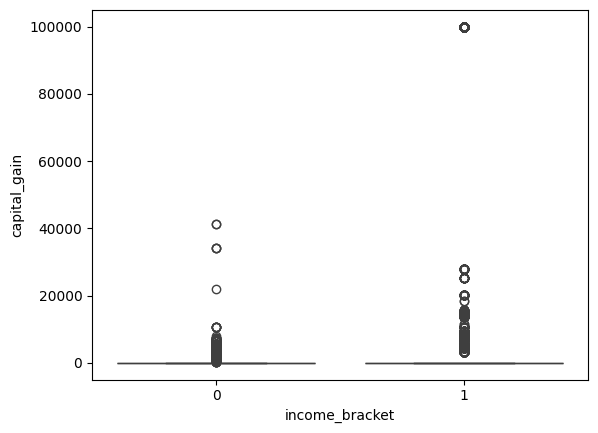

In [32]:
sns.boxplot(x="income_bracket", y="capital_gain", data=train)

The capital_gain variable is extremely right-skewed, with the majority of individuals reporting zero investment income. However, individuals with significant capital gains are disproportionately represented in the >50K income group. This suggests that capital gains may serve as a strong predictive feature for higher income brackets.

In [33]:
pd.crosstab(train["occupation"], train["income_bracket"], normalize="index")

income_bracket,0,1
occupation,,
Adm-clerical,0.866093,0.133907
Armed-Forces,0.888889,0.111111
Craft-repair,0.774410,0.225590
Exec-managerial,0.514658,0.485342
Farming-fishing,0.883485,0.116515
Handlers-cleaners,0.938473,0.061527
Machine-op-inspct,0.875764,0.124236
Other-service,0.958866,0.041134
Priv-house-serv,0.992908,0.007092


In [34]:
pd.crosstab(train["education_num"], train["income_bracket"], normalize="index")

income_bracket,0,1
education_num,,
1,1.000000,0.000000
2,0.959732,0.040268
3,0.958188,0.041812
4,0.937050,0.062950
5,0.945055,0.054945
6,0.928049,0.071951
7,0.943702,0.056298
8,0.923077,0.076923
9,0.835672,0.164328


In [35]:
train[num_cols + ["income_bracket"]].corr()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,income_bracket
age,1.000000,-0.076279,0.043203,0.080162,0.060141,0.101348,0.242017
fnlwgt,-0.076279,1.000000,-0.045199,0.000420,-0.009755,-0.023033,-0.008992
education_num,0.043203,-0.045199,1.000000,0.124455,0.079613,0.152842,0.335413
capital_gain,0.080162,0.000420,0.124455,1.000000,-0.032255,0.080429,0.221204
capital_loss,0.060141,-0.009755,0.079613,-0.032255,1.000000,0.052380,0.150026
hours_per_week,0.101348,-0.023033,0.152842,0.080429,0.052380,1.000000,0.229435
income_bracket,0.242017,-0.008992,0.335413,0.221204,0.150026,0.229435,1.000000


<Axes: xlabel='income_bracket', ylabel='hours_per_week'>

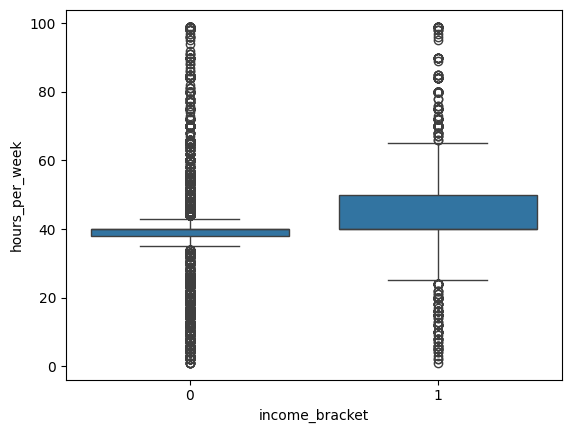

In [36]:
sns.boxplot(x="income_bracket", y="hours_per_week", data=train)

Individuals earning more than $50K tend to work slightly longer hours per week on average. However, the distributions overlap significantly, indicating that working hours alone is not a strong predictor of income level.

In [37]:
pd.crosstab(train["hours_per_week"], train["income_bracket"], normalize="index")

income_bracket,0,1
hours_per_week,,
1,0.857143,0.142857
2,0.866667,0.133333
3,0.958333,0.041667
4,0.925926,0.074074
5,0.842105,0.157895
...,...,...
95,0.500000,0.500000
96,0.800000,0.200000
97,0.500000,0.500000


<Axes: xlabel='income_bracket', ylabel='capital_gain'>

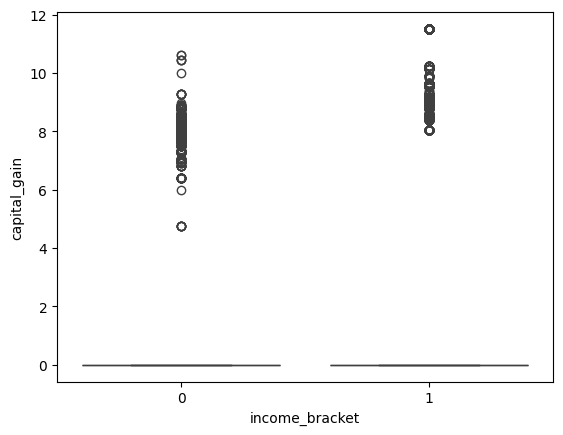

In [38]:
sns.boxplot(
    x="income_bracket",
    y=np.log1p(train["capital_gain"]),
    data=train
)

In [39]:
train["has_capital_gain"] = (train["capital_gain"] > 0).astype(int)
test["has_capital_gain"] = (test["capital_gain"] > 0).astype(int)

## 3. Modeling

In [40]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import GridSearchCV

In [41]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

X_train = train.drop("income_bracket", axis=1)
y_train = train["income_bracket"]

X_test = test.drop("income_bracket", axis=1)
y_test = test["income_bracket"]

X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc = preprocessor.transform(X_test)

print(X_train_enc.shape, X_test_enc.shape)

(30139, 88) (15055, 88)


In [42]:
#Baseline LR
logreg = LogisticRegression(max_iter=2000)
logreg.fit(X_train_enc, y_train)

pred = logreg.predict(X_test_enc)
prob = logreg.predict_proba(X_test_enc)[:, 1]

print("Accuracy:", accuracy_score(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, prob))

Accuracy: 0.8476253736300232
ROC-AUC: 0.9031028954978757


In [43]:
#Baseline Random Forest
rfc = RandomForestClassifier()
rfc.fit(X_train_enc, y_train)

rfc_pred = rfc.predict(X_test_enc)
rfc_prob = rfc.predict_proba(X_test_enc)[:,1]

print("Accuracy:", accuracy_score(y_test, rfc_pred))
print("ROC-AUC:", roc_auc_score(y_test, rfc_prob))

Accuracy: 0.8486217203586848
ROC-AUC: 0.9011212348411821


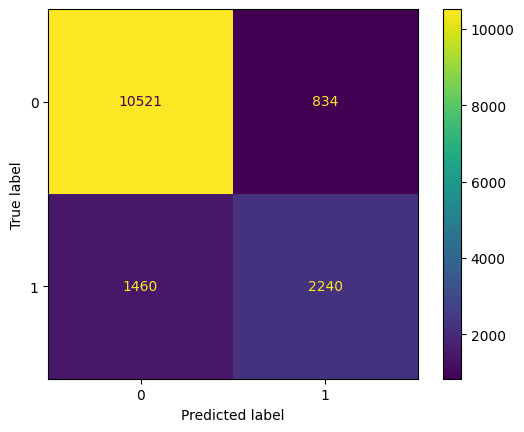

In [44]:
ConfusionMatrixDisplay.from_predictions(y_test, pred)

Simpler models can perform competitively with more complex models on structured tabular data.

In [45]:
#Slightly Tuned RFC
rfc = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
#Baseline Random Forest
rfc.fit(X_train_enc, y_train)

rfc_pred = rfc.predict(X_test_enc)
rfc_prob = rfc.predict_proba(X_test_enc)[:,1]

print("Accuracy:", accuracy_score(y_test, rfc_pred))
print("ROC-AUC:", roc_auc_score(y_test, rfc_prob))

Accuracy: 0.8609764197940883
ROC-AUC: 0.9145038737548646


In [46]:
feature_names = preprocessor.get_feature_names_out()

importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rfc.feature_importances_
}).sort_values("importance", ascending=False)

importance.head(15)

,feature,importance
3,num__capital_gain,0.160538
2,num__education_num,0.133590
15,cat__marital_status_Married-civ-spouse,0.126658
34,cat__relationship_Husband,0.085125
0,num__age,0.078709
5,num__hours_per_week,0.049578
17,cat__marital_status_Never-married,0.048088
4,num__capital_loss,0.037803
23,cat__occupation_Exec-managerial,0.034179
29,cat__occupation_Prof-specialty,0.026776


In [47]:
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    alpha=0.0001,
    batch_size=256,
    learning_rate_init=0.001,
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=42
)

mlp.fit(X_train_enc, y_train)

mlp_pred = mlp.predict(X_test_enc)
mlp_prob = mlp.predict_proba(X_test_enc)[:, 1]

print("Accuracy:", accuracy_score(y_test, mlp_pred))
print("ROC-AUC:", roc_auc_score(y_test, mlp_prob))

Accuracy: 0.8478246429757555
ROC-AUC: 0.9055382079569663


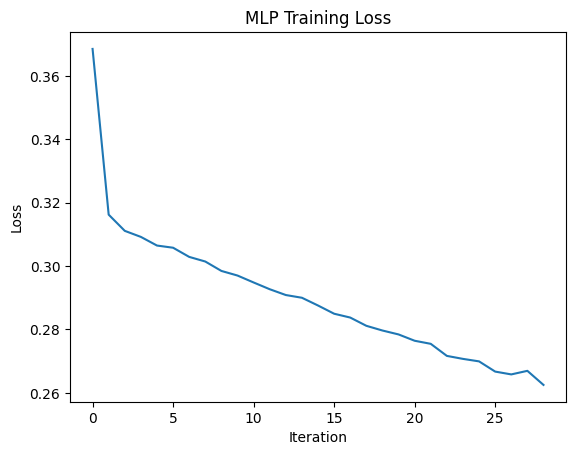

In [48]:
plt.plot(mlp.loss_curve_)
plt.title("MLP Training Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

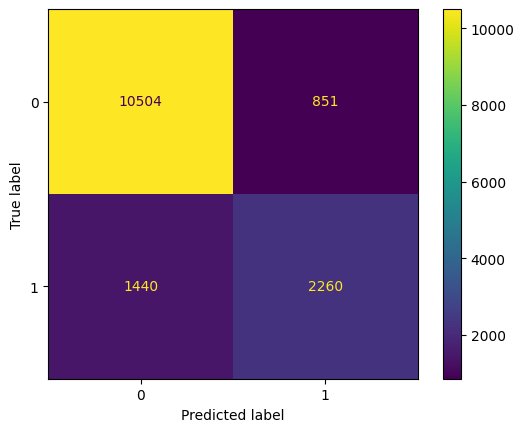

In [49]:
ConfusionMatrixDisplay.from_predictions(y_test, mlp_pred)

Model Performance Comparison

Logistic Regression
Accuracy: 0.8476
ROC-AUC: 0.9031

Random Forest (Tuned)
Accuracy: 0.8610
ROC-AUC: 0.9145

MLP Neural Network
Accuracy: 0.8478
ROC-AUC: 0.9055


While neural networks are powerful models, they did not outperform tree-based methods on this structured tabular dataset. The tuned Random Forest achieved the best predictive performance, suggesting that ensemble decision trees are better suited for capturing the feature interactions present in the Adult Census dataset.

In [50]:
#Deeper MLP
deep_mlp = MLPClassifier(
    hidden_layer_sizes=(256,128,64),
    alpha=0.0005,
    max_iter=300,
    early_stopping=True
)

deep_mlp.fit(X_train_enc, y_train)

deep_mlp_pred = deep_mlp.predict(X_test_enc)
deep_mlp_prob = deep_mlp.predict_proba(X_test_enc)[:, 1]

print("Accuracy:", accuracy_score(y_test, deep_mlp_pred))
print("ROC-AUC:", roc_auc_score(y_test, deep_mlp_prob))

Accuracy: 0.8493523746263699
ROC-AUC: 0.9086937412974401


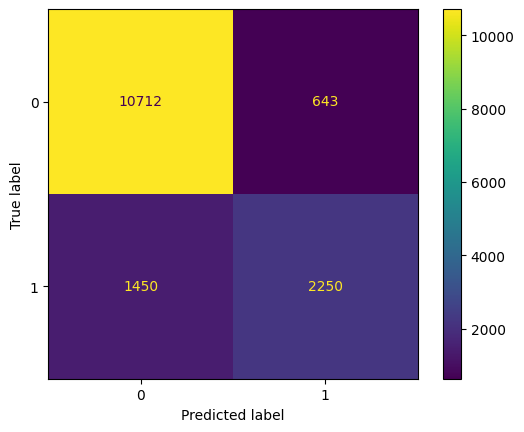

In [51]:

ConfusionMatrixDisplay.from_predictions(y_test, rfc_pred)

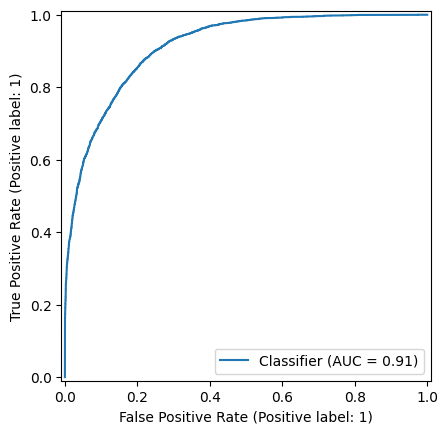

In [52]:
RocCurveDisplay.from_predictions(y_test, rfc_prob)

<Axes: ylabel='feature'>

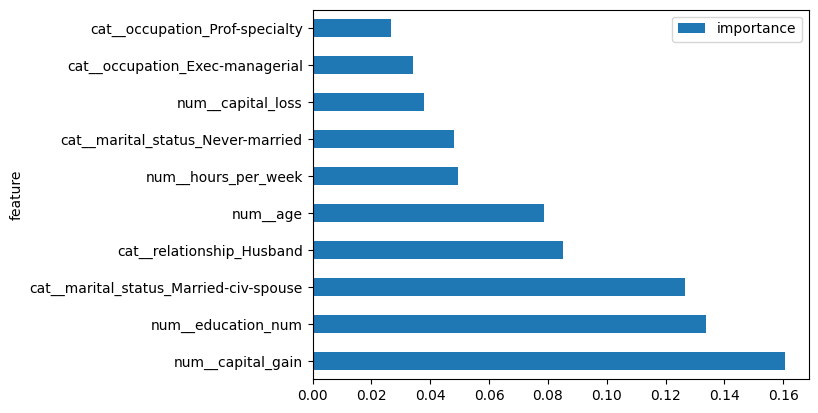

In [53]:
importance.head(10).plot.barh(x="feature", y="importance")

- Education level and capital gains are the strongest predictors of high income.
- Married individuals and household primary earners show higher income probability.
- Age and hours worked have moderate influence on income classification.
- Tree-based models outperform neural networks on this tabular dataset.

- Dataset is from the 1994 US Census and may not reflect modern economic patterns.
- Some socioeconomic variables may introduce bias.
- Categorical encoding may influence neural network performance.

This analysis demonstrates that socioeconomic variables such as education, investment income, and household role strongly influence income classification. Among the evaluated models, the tuned Random Forest provided the best predictive performance, outperforming both logistic regression and neural network approaches. These findings highlight the effectiveness of tree-based ensemble models for structured tabular datasets.

In [54]:
#GridSearchCV with Random Forest
#param_grid = {
#    "n_estimators": [200, 300, 500],
#    "max_depth": [None, 10, 20],
#    "min_samples_split": [2, 5, 10],
#    "min_samples_leaf": [1, 3, 5],
#    "max_features": ["sqrt", "log2"]
#}

param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [None, 20],
    "min_samples_split": [5, 10],
    "min_samples_leaf": [3, 5],
    "max_features": ["sqrt"]
}

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_enc, y_train)

best_rf = grid_search.best_estimator_

rf_pred = best_rf.predict(X_test_enc)
rf_prob = best_rf.predict_proba(X_test_enc)[:, 1]

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)
print("Test Accuracy:", accuracy_score(y_test, rf_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, rf_prob))

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 10, 'n_estimators': 300}
Best CV Score: 0.9165239985888307
Test Accuracy: 0.8617734971770176
Test ROC-AUC: 0.9154190200768799


Hyperparameter tuning improved Random Forest performance over both the logistic regression baseline and the untuned forest. The final model achieved a test ROC-AUC of 0.9154, with cross-validation performance closely matching held-out test performance, indicating good generalization.


## Model Comparison

To evaluate the Adult Census dataset, three classification approaches were compared:

- **Logistic Regression** as an interpretable linear baseline
- **Random Forest** as a nonlinear ensemble model
- **MLP Neural Network** as a deep learning baseline for tabular data

The tuned Random Forest achieved the strongest overall performance, outperforming both the linear baseline and the neural network.



| Model | Accuracy | ROC-AUC |
|---|---:|---:|
| Logistic Regression | 0.8476 | 0.9031 |
| MLP Neural Network | 0.8478 | 0.9055 |
| Random Forest (Tuned) | **0.8618** | **0.9154** |


The Random Forest classifier produced the best balance of accuracy and class separation, suggesting that nonlinear feature interactions are present in the dataset and are better captured by ensemble tree methods than by linear or neural network baselines.

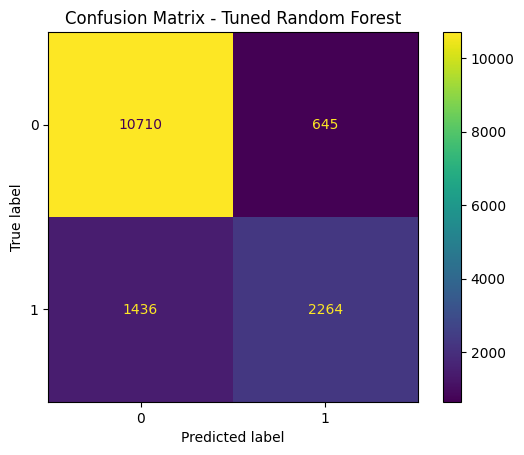

In [55]:
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred)
plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()

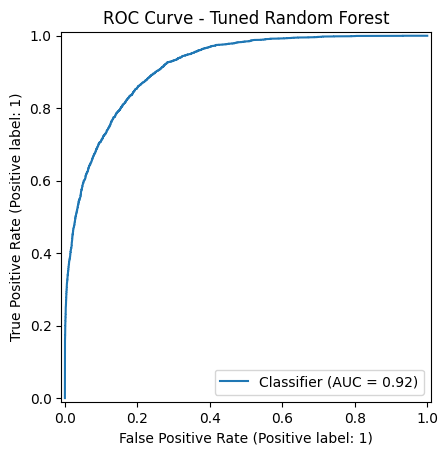

In [56]:
RocCurveDisplay.from_predictions(y_test, rf_prob)
plt.title("ROC Curve - Tuned Random Forest")
plt.show()

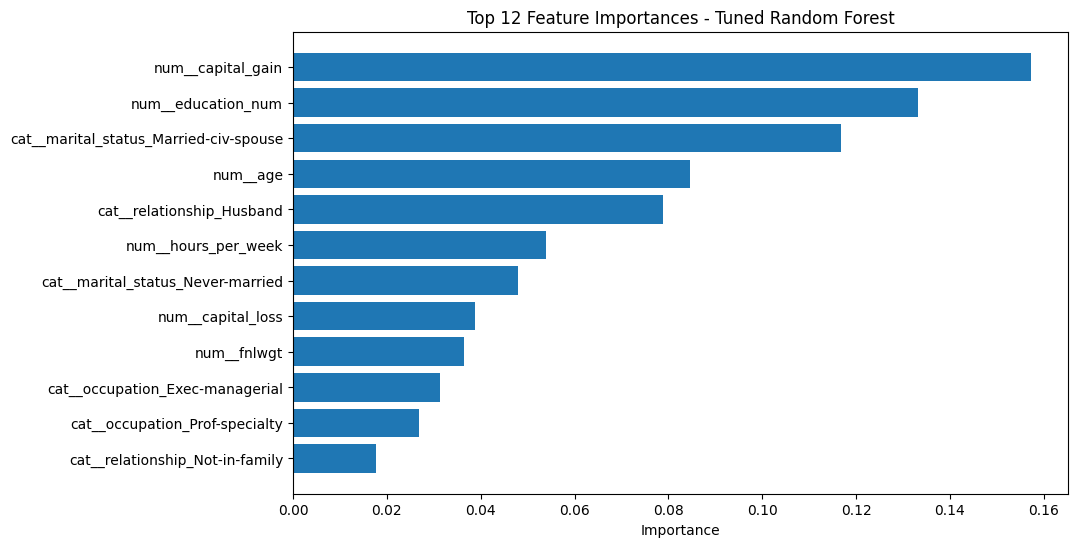

In [57]:
feature_names = preprocessor.get_feature_names_out()

importance = pd.DataFrame({
    "feature": feature_names,
    "importance": best_rf.feature_importances_
}).sort_values("importance", ascending=False)

top_features = importance.head(12).sort_values("importance")

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.title("Top 12 Feature Importances - Tuned Random Forest")
plt.xlabel("Importance")
plt.show()